# Reviewer-Proof Z-Score Statistics for Circuit Motif Analysis

**Six-phase statistical analysis of Neuronpedia attribution graphs:**

This notebook demonstrates a rigorous statistical pipeline for analyzing network motifs in neural circuit attribution graphs. The pipeline includes:

- **Phase A**: 3-node motif Z-scores with configurable null models
- **Phase B**: 4-node motif Z-scores on qualifying (heavily pruned) graphs
- **Phase C**: Benjamini-Hochberg FDR correction across all tests
- **Phase D**: Pruning sensitivity sweep across multiple thresholds
- **Phase E**: Null model convergence diagnostics
- **Phase F**: Layer-preserving null model validation

Each graph is compared against DAG-constrained null models using edge-swap randomization, producing Z-scores that quantify motif over/under-representation.

In [1]:
import subprocess, sys
def _pip(*a): subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *a])

# igraph — NOT pre-installed on Colab, always install
_pip('igraph')

# Core packages — pre-installed on Colab, install locally only
# Colab versions: numpy==2.0.2, scipy==1.16.3, statsmodels==0.14.6, matplotlib==3.10.0
# Local: use scipy==1.15.3 (latest compatible with Python 3.10)
if 'google.colab' not in sys.modules:
    _pip('numpy==2.0.2', 'scipy==1.15.3', 'statsmodels==0.14.6', 'matplotlib==3.10.0')


[notice] A new release of pip is available: 23.0.1 -> 26.0.1
[notice] To update, run: python3 -m pip install --upgrade pip



[notice] A new release of pip is available: 23.0.1 -> 26.0.1
[notice] To update, run: python3 -m pip install --upgrade pip


In [2]:
import json
import math
import os
import random
import time

import numpy as np
from scipy import stats as scipy_stats
from statsmodels.stats.multitest import multipletests
import igraph
import matplotlib.pyplot as plt

In [3]:
GITHUB_DATA_URL = "https://raw.githubusercontent.com/ai-inventor-outputs/ai-invention-582cc7-circuit-motif-spectroscopy-discovering-u/main/experiment_iter5_reviewer_proof/demo/mini_demo_data.json"

def load_data():
    try:
        import urllib.request
        with urllib.request.urlopen(GITHUB_DATA_URL) as response:
            return json.loads(response.read().decode())
    except Exception: pass
    if os.path.exists("mini_demo_data.json"):
        with open("mini_demo_data.json") as f: return json.load(f)
    raise FileNotFoundError("Could not load mini_demo_data.json")

In [4]:
data = load_data()
print(f"Loaded {len(data['datasets'][0]['examples'])} examples")
for ex in data['datasets'][0]['examples']:
    g = json.loads(ex['output'])
    print(f"  [{ex['metadata_fold']}] {ex['input'][:50]}  nodes={len(g['nodes'])} links={len(g['links'])}")

Loaded 3 examples
  [antonym] The opposite of clean is  nodes=986 links=5000
  [arithmetic] 12 + 19 =  nodes=1027 links=5000
  [code_completion] def add(a, b):
    return  nodes=1283 links=5000


## Configuration

All tunable parameters for the analysis pipeline. Values below are set for a fast demo run; original production values are noted in comments.

In [5]:
# --- Tunable parameters (scaled for demo; original values in comments) ---
MAX_EXAMPLES = 3          # original: 200 (demo has 3 graphs)
N_NULLS_A = 50            # original: 50 — null models per graph for Phase A
N_NULLS_B = 20            # original: 20 — null models for Phase B (4-node)
N_NULLS_D = 15            # original: 15 — null models for Phase D (pruning sweep)
N_NULLS_F = 15            # original: 15 — null models for Phase F (layer-preserving)
BASELINE_NULLS = 20       # original: 20 — baseline comparison nulls
PRUNING_PCT_PRIMARY = 75  # original: 75 — weight percentile for primary pruning
PRUNING_PCT_4NODE = 99    # original: 99 — aggressive pruning for 4-node analysis
PRUNING_THRESHOLDS_D = [60, 75, 90]  # original: [60, 75, 90]
MAX_VCOUNT_4NODE = 500    # original: 500 — max node count for 4-node analysis
N_GRAPHS_D_TARGET = 3     # original: 48 (demo has 3 graphs)
N_GRAPHS_E = 3            # original: 20 (demo has 3 graphs)
SWAP_FACTOR = 10          # original: 10 — edge swap attempts per edge

print("Configuration loaded:")
print(f"  MAX_EXAMPLES={MAX_EXAMPLES}, N_NULLS_A={N_NULLS_A}, N_NULLS_B={N_NULLS_B}")
print(f"  N_NULLS_D={N_NULLS_D}, N_NULLS_F={N_NULLS_F}, SWAP_FACTOR={SWAP_FACTOR}")

Configuration loaded:
  MAX_EXAMPLES=3, N_NULLS_A=50, N_NULLS_B=20
  N_NULLS_D=15, N_NULLS_F=15, SWAP_FACTOR=10


## Helper Functions

Core graph operations: isoclass mapping (enumerating valid DAG motifs), graph parsing/pruning, and two null model generators (degree-preserving and layer-preserving edge swaps).

In [6]:
def build_isoclass_mappings():
    """Build isoclass-ID to structure mappings for 3/4-node DAG motifs."""
    # ---- 3-node ----
    dag_3 = {}
    for i in range(16):
        g = igraph.Graph.Isoclass(n=3, cls=i, directed=True)
        if not (g.is_dag() and g.is_connected(mode="weak")):
            continue
        edges = g.get_edgelist()
        ne = len(edges)
        if ne == 3:
            label = "030T"
        elif ne == 2:
            od = [g.degree(v, mode="out") for v in range(3)]
            id_ = [g.degree(v, mode="in") for v in range(3)]
            if max(od) == 2:
                label = "021D"
            elif max(id_) == 2:
                label = "021U"
            else:
                label = "021C"
        else:
            label = f"unk{ne}"
        dag_3[i] = {"label": label, "edges": edges, "n_edges": ne}

    # ---- 4-node ----
    dag_4 = {}
    for i in range(218):
        g = igraph.Graph.Isoclass(n=4, cls=i, directed=True)
        if not (g.is_dag() and g.is_connected(mode="weak")):
            continue
        edges = tuple(sorted(g.get_edgelist()))
        dag_4[i] = {"edges": edges, "n_edges": len(edges)}

    print(f"3-node DAG motifs: {len(dag_3)} types — "
          + ", ".join(f"id={k}->{v['label']}" for k, v in sorted(dag_3.items())))
    print(f"4-node DAG motifs: {len(dag_4)} types identified")
    return dag_3, dag_4


def _layer_int(layer_str):
    """Convert layer string to int ('E' -> -1)."""
    if layer_str in ("E", "e"):
        return -1
    try:
        return int(layer_str)
    except (ValueError, TypeError):
        return -2


def parse_and_prune(graph_json, weight_percentile=75.0):
    """Parse graph JSON and prune by |weight| percentile."""
    nodes = graph_json["nodes"]
    links = graph_json.get("links", graph_json.get("edges", []))

    nid_to_idx = {n["node_id"]: i for i, n in enumerate(nodes)}
    layers = [_layer_int(n.get("layer", "0")) for n in nodes]

    valid_links = []
    abs_w = []
    for lk in links:
        s, t = lk["source"], lk["target"]
        if s in nid_to_idx and t in nid_to_idx:
            w = float(lk.get("weight", 0.0))
            valid_links.append((nid_to_idx[s], nid_to_idx[t], w))
            abs_w.append(abs(w))

    if not abs_w:
        return None, {"error": "no_valid_links"}

    thresh = float(np.percentile(abs_w, weight_percentile))
    kept = [(s, t) for s, t, w in valid_links if abs(w) >= thresh]

    if len(kept) < 5:
        return None, {"error": "too_few_edges"}

    g = igraph.Graph(n=len(nodes), edges=kept, directed=True)
    g.vs["layer"] = layers
    g.simplify(multiple=True, loops=True, combine_edges="max")

    iso = [v.index for v in g.vs if g.degree(v) == 0]
    if iso:
        g.delete_vertices(iso)

    if g.vcount() < 10:
        return None, {"error": f"vcount={g.vcount()}"}
    if not g.is_dag():
        return None, {"error": "not_dag"}

    return g, {"n_nodes": g.vcount(), "n_edges": g.ecount()}


def generate_dag_null(edges, n_verts, topo_ranks, n_swap_factor=10, rng=None):
    """Goni Method 1 DAG-constrained edge swap. Returns (new_edges, acc_rate)."""
    if rng is None:
        rng = random.Random()
    el = list(edges)
    ne = len(el)
    if ne < 2:
        return el, 0.0

    eset = set(el)
    n_att = n_swap_factor * ne
    n_acc = 0

    for _ in range(n_att):
        i1 = rng.randrange(ne)
        i2 = rng.randrange(ne)
        if i1 == i2:
            continue
        u1, v1 = el[i1]
        u2, v2 = el[i2]
        if u1 == u2 or v1 == v2 or u1 == v2 or u2 == v1:
            continue
        e1n = (u1, v2)
        e2n = (u2, v1)
        if e1n in eset or e2n in eset:
            continue
        if topo_ranks[u1] >= topo_ranks[v2] or topo_ranks[u2] >= topo_ranks[v1]:
            continue
        eset.discard((u1, v1))
        eset.discard((u2, v2))
        eset.add(e1n)
        eset.add(e2n)
        el[i1] = e1n
        el[i2] = e2n
        n_acc += 1

    return el, n_acc / max(n_att, 1)


def generate_layer_preserving_null(edges, vlayers, topo_ranks, n_swap_factor=10, rng=None):
    """Layer-preserving DAG null: swaps only within same (src_layer, tgt_layer)."""
    if rng is None:
        rng = random.Random()

    groups = {}
    for i, (u, v) in enumerate(edges):
        key = (vlayers[u], vlayers[v])
        groups.setdefault(key, []).append(i)

    el = list(edges)
    eset = set(el)
    ne = len(el)
    n_att = n_swap_factor * ne
    n_acc = 0

    swap_groups = {k: v for k, v in groups.items() if len(v) >= 2}
    if not swap_groups:
        return el, 0.0

    gkeys = list(swap_groups.keys())
    gwts = [len(swap_groups[k]) for k in gkeys]
    tot = sum(gwts)

    for _ in range(n_att):
        r = rng.randrange(tot)
        c = 0
        gk = gkeys[0]
        for k, w in zip(gkeys, gwts):
            c += w
            if r < c:
                gk = k
                break
        gi = swap_groups[gk]
        if len(gi) < 2:
            continue
        i1, i2 = rng.sample(gi, 2)
        u1, v1 = el[i1]
        u2, v2 = el[i2]
        if u1 == u2 or v1 == v2 or u1 == v2 or u2 == v1:
            continue
        e1n = (u1, v2)
        e2n = (u2, v1)
        if e1n in eset or e2n in eset:
            continue
        if topo_ranks[u1] >= topo_ranks[v2] or topo_ranks[u2] >= topo_ranks[v1]:
            continue
        eset.discard((u1, v1))
        eset.discard((u2, v2))
        eset.add(e1n)
        eset.add(e2n)
        el[i1] = e1n
        el[i2] = e2n
        n_acc += 1

    return el, n_acc / max(n_att, 1)


print("Helper functions defined.")

Helper functions defined.


## Data Preparation

Parse loaded graph examples, build isoclass mappings, and pre-prune graphs at the primary weight percentile threshold.

In [7]:
t0 = time.time()

# Load graph records from demo data
all_g = []
for ex in data["datasets"][0]["examples"][:MAX_EXAMPLES]:
    try:
        graph_json = json.loads(ex["output"])
    except json.JSONDecodeError:
        print(f"Bad JSON in example, skipping")
        continue
    all_g.append({
        "input": ex["input"],
        "slug": ex.get("metadata_slug", ""),
        "domain": ex.get("metadata_fold", ""),
        "correct": ex.get("metadata_model_correct", "unknown"),
        "difficulty": ex.get("metadata_difficulty", "unknown"),
        "graph_json": graph_json,
        "metadata": {k: v for k, v in ex.items() if k.startswith("metadata_")},
    })

print(f"Loaded {len(all_g)} graphs")

# Build isoclass mappings
dag3, dag4 = build_isoclass_mappings()

# Pre-prune at primary threshold
print(f"\nPre-pruning at {PRUNING_PCT_PRIMARY}th percentile ...")
pruned = []
for i, rec in enumerate(all_g):
    g, info = parse_and_prune(rec["graph_json"], PRUNING_PCT_PRIMARY)
    if g is None:
        print(f"  Graph {i} ({rec['slug']}): {info}")
        continue
    pruned.append({
        "idx": i,
        "slug": rec["slug"],
        "domain": rec["domain"],
        "correct": rec["correct"],
        "edge_list": g.get_edgelist(),
        "nv": g.vcount(),
        "vlayers": list(g.vs["layer"]),
    })

print(f"Pruned: {len(pruned)}/{len(all_g)} valid")
if pruned:
    nvs = [p["nv"] for p in pruned]
    nes = [len(p["edge_list"]) for p in pruned]
    print(f"  Node counts: min={min(nvs)} med={int(np.median(nvs))} max={max(nvs)}")
    print(f"  Edge counts: min={min(nes)} med={int(np.median(nes))} max={max(nes)}")

Loaded 3 graphs
3-node DAG motifs: 4 types — id=2->021U, id=4->021C, id=6->021D, id=7->030T
4-node DAG motifs: 24 types identified

Pre-pruning at 75th percentile ...
Pruned: 3/3 valid
  Node counts: min=690 med=746 max=833
  Edge counts: min=1250 med=1250 max=1250


## Phase A: 3-Node Motif Z-Scores

For each pruned graph, count 3-node subgraph motifs in the real graph and in N null models generated by DAG-constrained edge swaps. Compute Z-scores comparing real vs. null distributions, plus baseline Z-scores from fewer nulls and convergence tracking data.

In [8]:
print(f"PHASE A: 3-node x {N_NULLS_A} nulls x {len(pruned)} graphs")
ids3 = list(dag3.keys())

res_a = []
for pg in pruned:
    idx, slug, domain, correct = pg["idx"], pg["slug"], pg["domain"], pg["correct"]
    el, nv, vlayers = pg["edge_list"], pg["nv"], pg["vlayers"]
    seed = 42 + idx * 1000
    try:
        g = igraph.Graph(n=nv, edges=el, directed=True)
        topo = g.topological_sorting()
        tr = {v: i for i, v in enumerate(topo)}
        rc_raw = g.motifs_randesu(size=3)
        rc = [0 if (x != x) else int(x) for x in rc_raw]
        del g

        ncm = []
        acc_rates = []
        for j in range(N_NULLS_A):
            ne_list, ar = generate_dag_null(el, nv, tr, SWAP_FACTOR, random.Random(seed + j + 1))
            acc_rates.append(ar)
            gn = igraph.Graph(n=nv, edges=ne_list, directed=True)
            nc_raw = gn.motifs_randesu(size=3)
            ncm.append([0 if (x != x) else int(x) for x in nc_raw])
            del gn

        na = np.array(ncm, dtype=np.float64)
        mu = na.mean(axis=0)
        sd = na.std(axis=0, ddof=1)

        mr, bl, conv = {}, {}, {}
        bn = min(BASELINE_NULLS, N_NULLS_A)
        ba = na[:bn]
        bmu, bsd = ba.mean(axis=0), ba.std(axis=0, ddof=1)

        for mid in ids3:
            if sd[mid] == 0:
                z = 0.0 if rc[mid] == mu[mid] else 10.0 * np.sign(rc[mid] - mu[mid])
            else:
                z = (rc[mid] - mu[mid]) / sd[mid]
            ep = float(np.mean(na[:, mid] >= rc[mid]))
            ep = max(ep, 1.0 / (N_NULLS_A + 1))
            mr[str(mid)] = {"real_count": rc[mid], "null_mean": round(float(mu[mid]), 4),
                            "null_std": round(float(sd[mid]), 4), "zscore": round(float(z), 4),
                            "empirical_p": round(float(ep), 6)}

            if bsd[mid] == 0:
                bz = 0.0 if rc[mid] == bmu[mid] else 10.0 * np.sign(rc[mid] - bmu[mid])
            else:
                bz = (rc[mid] - bmu[mid]) / bsd[mid]
            bl[str(mid)] = {"zscore": round(float(bz), 4)}
            conv[str(mid)] = {"real_count": rc[mid], "null_counts": na[:, mid].tolist()}

        res_a.append({"idx": idx, "slug": slug, "domain": domain, "correct": correct,
                       "n_nodes": nv, "n_edges": len(el), "motif_results": mr,
                       "baseline_results": bl, "convergence_data": conv,
                       "mean_acceptance_rate": round(float(np.mean(acc_rates)), 4),
                       "n_nulls": N_NULLS_A, "error": None})
        print(f"  Graph {idx} ({slug}): Z-scores = "
              + ", ".join(f"{dag3[m]['label']}={mr[str(m)]['zscore']:.1f}" for m in ids3))
    except Exception as e:
        res_a.append({"idx": idx, "slug": slug, "domain": domain, "correct": correct, "error": str(e)})
        print(f"  Graph {idx} ERROR: {e}")

res_a.sort(key=lambda r: r.get("idx", -1))
t_a = time.time() - t0
print(f"\nPhase A done: {sum(1 for r in res_a if not r.get('error'))}/{len(res_a)} ok ({t_a:.1f}s)")

PHASE A: 3-node x 50 nulls x 3 graphs


  Graph 0 (m4-antonym-013-db7d1359): Z-scores = 021U=-15.7, 021C=-15.7, 021D=-15.7, 030T=15.7


  Graph 1 (m4-arithmetic-007-8883759f): Z-scores = 021U=-30.7, 021C=-30.7, 021D=-30.7, 030T=30.7


  Graph 2 (m4-code_completion-000-7016315e): Z-scores = 021U=-17.0, 021C=-17.0, 021D=-17.0, 030T=17.0

Phase A done: 3/3 ok (2.4s)


## Phase B: 4-Node Motif Z-Scores

Aggressively prune graphs (99th percentile) to reduce node count, then compute 4-node motif Z-scores on qualifying small graphs (vcount <= 500).

In [9]:
print(f"PHASE B: 4-node x {N_NULLS_B} nulls")
ids4 = list(dag4.keys())

# Find qualifying graphs (small enough for 4-node motif counting)
qualifying = []
for i, rec in enumerate(all_g):
    g, info = parse_and_prune(rec["graph_json"], weight_percentile=PRUNING_PCT_4NODE)
    if g is not None and g.vcount() <= MAX_VCOUNT_4NODE:
        qualifying.append({"idx": i, "slug": rec["slug"], "domain": rec["domain"],
                           "el": g.get_edgelist(), "nv": g.vcount()})

# Fallback to higher pruning if too few qualify
if len(qualifying) == 0:
    for fallback_pct in [99.5, 99.9]:
        print(f"  Trying {fallback_pct}th percentile fallback ...")
        qualifying = []
        for i, rec in enumerate(all_g):
            g, info = parse_and_prune(rec["graph_json"], weight_percentile=fallback_pct)
            if g is not None and g.vcount() <= MAX_VCOUNT_4NODE:
                qualifying.append({"idx": i, "slug": rec["slug"], "domain": rec["domain"],
                                   "el": g.get_edgelist(), "nv": g.vcount()})
        if qualifying:
            break

print(f"  B qualifying: {len(qualifying)} graphs (vcount<={MAX_VCOUNT_4NODE})")

res_b = []
for q in qualifying:
    idx, slug, domain = q["idx"], q["slug"], q["domain"]
    el, nv = q["el"], q["nv"]
    seed = 100000 + idx * 1000
    try:
        g = igraph.Graph(n=nv, edges=el, directed=True)
        topo = g.topological_sorting()
        tr = {v: i for i, v in enumerate(topo)}
        rc_raw = g.motifs_randesu(size=4)
        rc = [0 if (x != x) else int(x) for x in rc_raw]
        del g

        ncm, acc_rates = [], []
        for j in range(N_NULLS_B):
            ne_list, ar = generate_dag_null(el, nv, tr, SWAP_FACTOR, random.Random(seed + j + 1))
            acc_rates.append(ar)
            gn = igraph.Graph(n=nv, edges=ne_list, directed=True)
            nc_raw = gn.motifs_randesu(size=4)
            ncm.append([0 if (x != x) else int(x) for x in nc_raw])
            del gn

        na = np.array(ncm, dtype=np.float64)
        mu, sd = na.mean(axis=0), na.std(axis=0, ddof=1)

        mr = {}
        for mid in ids4:
            if sd[mid] == 0:
                z = 0.0 if rc[mid] == mu[mid] else 10.0 * np.sign(rc[mid] - mu[mid])
            else:
                z = (rc[mid] - mu[mid]) / sd[mid]
            ep = float(np.mean(na[:, mid] >= rc[mid]))
            ep = max(ep, 1.0 / (N_NULLS_B + 1))
            mr[str(mid)] = {"real_count": rc[mid], "null_mean": round(float(mu[mid]), 4),
                            "null_std": round(float(sd[mid]), 4), "zscore": round(float(z), 4),
                            "empirical_p": round(float(ep), 6)}

        res_b.append({"idx": idx, "slug": slug, "domain": domain, "n_nodes": nv,
                       "n_edges": len(el), "motif_results": mr,
                       "mean_acceptance_rate": round(float(np.mean(acc_rates)), 4),
                       "n_nulls": N_NULLS_B, "error": None})
        print(f"  Graph {idx} ({slug}): {nv} nodes, {len(el)} edges — 4-node analysis done")
    except Exception as e:
        res_b.append({"idx": idx, "slug": slug, "domain": domain, "error": str(e)})
        print(f"  Graph {idx} ERROR: {e}")

res_b.sort(key=lambda r: r.get("idx", -1))
t_b = time.time() - t0
print(f"\nPhase B done: {sum(1 for r in res_b if not r.get('error'))}/{len(res_b)} ok ({t_b:.1f}s)")

PHASE B: 4-node x 20 nulls
  B qualifying: 3 graphs (vcount<=500)
  Graph 0 (m4-antonym-013-db7d1359): 55 nodes, 50 edges — 4-node analysis done
  Graph 1 (m4-arithmetic-007-8883759f): 58 nodes, 50 edges — 4-node analysis done
  Graph 2 (m4-code_completion-000-7016315e): 67 nodes, 50 edges — 4-node analysis done

Phase B done: 3/3 ok (2.4s)


## Phase C: Benjamini-Hochberg FDR Correction

Apply multiple testing correction to all empirical p-values from Phases A and B. This demonstrates how many apparently significant results survive FDR correction.

In [10]:
print("PHASE C: BH-FDR correction")
va = [r for r in res_a if not r.get("error")]
vb = [r for r in res_b if not r.get("error")]

# Collect 3-node p-values
p3, lab3 = [], []
for r in va:
    for mk, md in r["motif_results"].items():
        p3.append(md["empirical_p"])
        lab3.append((int(mk), r["idx"], r["domain"]))

# Collect 4-node p-values
p4, lab4 = [], []
for r in vb:
    for mk, md in r["motif_results"].items():
        p4.append(md["empirical_p"])
        lab4.append((int(mk), r["idx"], r["domain"]))

res_c = {"method": "Benjamini-Hochberg", "alpha": 0.05}

# 3-node FDR
if p3:
    pa = np.array(p3)
    rej, padj, _, _ = multipletests(pa, alpha=0.05, method="fdr_bh")
    npre = int((pa < 0.05).sum())
    npost = int(rej.sum())

    mds_pre, mds_post = {}, {}
    for i, (mid, gidx, dom) in enumerate(lab3):
        mk = str(mid)
        mds_pre.setdefault(mk, {}).setdefault(dom, []).append(bool(pa[i] < 0.05))
        mds_post.setdefault(mk, {}).setdefault(dom, []).append(bool(rej[i]))

    univ_pre = {mk: sum(1 for sigs in mds_pre[mk].values() if sum(sigs) > len(sigs)/2) for mk in mds_pre}
    univ_post = {mk: sum(1 for sigs in mds_post[mk].values() if sum(sigs) > len(sigs)/2) for mk in mds_post}

    res_c["3node"] = {"n_tests": len(p3), "n_rejected_pre_fdr": npre,
                      "n_rejected_post_fdr": npost,
                      "per_motif_universality_pre_fdr": univ_pre,
                      "per_motif_universality_post_fdr": univ_post}
    print(f"  3-node: {npre} -> {npost} significant (of {len(p3)} tests)")

# 4-node FDR
if p4:
    pa = np.array(p4)
    rej, _, _, _ = multipletests(pa, alpha=0.05, method="fdr_bh")
    res_c["4node"] = {"n_tests": len(p4), "n_rejected_pre_fdr": int((pa < 0.05).sum()),
                      "n_rejected_post_fdr": int(rej.sum())}
    print(f"  4-node: {int((pa<0.05).sum())} -> {int(rej.sum())} significant (of {len(p4)})")

# Combined FDR
all_p = p3 + p4
if all_p:
    pa = np.array(all_p)
    rej, _, _, _ = multipletests(pa, alpha=0.05, method="fdr_bh")
    res_c["combined"] = {"n_tests": len(all_p), "n_rejected_pre_fdr": int((pa < 0.05).sum()),
                         "n_rejected_post_fdr": int(rej.sum())}

print("Phase C done")

PHASE C: BH-FDR correction
  3-node: 3 -> 0 significant (of 12 tests)
  4-node: 3 -> 0 significant (of 72)
Phase C done


## Phase D: Pruning Sensitivity Sweep

Test how Z-scores change across different pruning thresholds to verify robustness of findings to the choice of pruning percentile. Computes Spearman correlations of Z-scores between threshold pairs.

In [11]:
print(f"PHASE D: Pruning sweep: {len(PRUNING_THRESHOLDS_D)} thresholds x {N_NULLS_D} nulls")

# Select graphs for sweep (stratified by domain)
dg = {}
for i, r in enumerate(all_g):
    dg.setdefault(r["domain"], []).append(i)

n_per = max(1, N_GRAPHS_D_TARGET // max(len(dg), 1))
sel_d = []
for d in sorted(dg):
    inds = sorted(dg[d])
    step = max(1, len(inds) // n_per)
    for j in range(0, len(inds), step):
        if len(sel_d) < N_GRAPHS_D_TARGET:
            sel_d.append(inds[j])

print(f"  D selected: {len(sel_d)} graphs")

res_d_per = []
for gi in sel_d:
    r = all_g[gi]
    for th in PRUNING_THRESHOLDS_D:
        seed = 200000 + gi * 100 + th
        try:
            g, info = parse_and_prune(r["graph_json"], weight_percentile=th)
            if g is None:
                res_d_per.append({"idx": gi, "slug": r["slug"], "threshold": th,
                                  "error": info.get("error", "prune_fail")})
                continue

            el = g.get_edgelist()
            nv = g.vcount()
            topo = g.topological_sorting()
            tr = {v: i for i, v in enumerate(topo)}
            rc_raw = g.motifs_randesu(size=3)
            rc = [0 if (x != x) else int(x) for x in rc_raw]
            del g

            ncm = []
            for j in range(N_NULLS_D):
                ne_list, _ = generate_dag_null(el, nv, tr, SWAP_FACTOR, random.Random(seed + j + 1))
                gn = igraph.Graph(n=nv, edges=ne_list, directed=True)
                nc_raw = gn.motifs_randesu(size=3)
                ncm.append([0 if (x != x) else int(x) for x in nc_raw])
                del gn

            na = np.array(ncm, dtype=np.float64)
            mu, sd = na.mean(axis=0), na.std(axis=0, ddof=1)

            mr = {}
            for mid in ids3:
                if sd[mid] == 0:
                    z = 0.0 if rc[mid] == mu[mid] else 10.0 * np.sign(rc[mid] - mu[mid])
                else:
                    z = (rc[mid] - mu[mid]) / sd[mid]
                mr[str(mid)] = {"zscore": round(float(z), 4)}

            res_d_per.append({"idx": gi, "slug": r["slug"], "domain": r["domain"],
                              "threshold": th, "n_nodes": nv, "n_edges": len(el),
                              "motif_results": mr, "error": None})
        except Exception as e:
            res_d_per.append({"idx": gi, "slug": r["slug"], "threshold": th, "error": str(e)})

# Stability analysis: Spearman correlation across thresholds
valid_d = [r for r in res_d_per if not r.get("error")]
gd = {}
for r in valid_d:
    gd.setdefault(r["idx"], {})[r["threshold"]] = r["motif_results"]

thresholds = sorted({r["threshold"] for r in valid_d})
stab_d = {}
for mid, info in dag3.items():
    mk = str(mid)
    zbt = {t: [] for t in thresholds}
    for gi in sorted(gd):
        for t in thresholds:
            z = gd[gi].get(t, {}).get(mk, {}).get("zscore", float("nan"))
            zbt[t].append(z)

    rho_mat = []
    for t1 in thresholds:
        row = []
        for t2 in thresholds:
            v1, v2 = np.array(zbt[t1]), np.array(zbt[t2])
            m = ~(np.isnan(v1) | np.isnan(v2))
            if m.sum() >= 3:
                try:
                    rho, _ = scipy_stats.spearmanr(v1[m], v2[m])
                    row.append(round(float(rho), 4) if not np.isnan(rho) else None)
                except Exception:
                    row.append(None)
            else:
                row.append(None)
        rho_mat.append(row)
    stab_d[mk] = {"label": info["label"], "spearman_rho_matrix": rho_mat, "thresholds": thresholds}

res_d = {"per_result": res_d_per, "stability": stab_d, "selected": sel_d, "thresholds": PRUNING_THRESHOLDS_D}

t_d = time.time() - t0
ok_d = sum(1 for r in res_d_per if not r.get("error"))
print(f"\nPhase D done: {ok_d}/{len(res_d_per)} tasks ok ({t_d:.1f}s)")

PHASE D: Pruning sweep: 3 thresholds x 15 nulls
  D selected: 3 graphs



Phase D done: 9/9 tasks ok (4.8s)


## Phase E: Convergence Diagnostics

Analyze how Z-scores stabilize as the number of null models increases, using the per-null count data stored during Phase A. Identifies the minimum number of nulls needed for reliable Z-score estimates.

In [12]:
print("PHASE E: Convergence diagnostics")

valid_e = [r for r in res_a if not r.get("error") and "convergence_data" in r]
if not valid_e:
    print("  No valid Phase A results for convergence")
    res_e = {"error": "no_data"}
else:
    step = max(1, len(valid_e) // N_GRAPHS_E)
    sel_e = valid_e[::step][:N_GRAPHS_E]

    cps = [cp for cp in [2, 3, 5, 10, 20, 30, 40, 50] if cp <= N_NULLS_A]
    if not cps:
        cps = [N_NULLS_A]

    per_graph_e = []
    all_conv_ns = []

    for r in sel_e:
        gc = {"idx": r["idx"], "slug": r["slug"]}
        for mk, cd in r["convergence_data"].items():
            rc = cd["real_count"]
            nc = np.array(cd["null_counts"])

            z_cp = []
            for cp in cps:
                sub = nc[:cp]
                m, s = float(sub.mean()), float(sub.std(ddof=1))
                if s == 0:
                    z = 0.0 if rc == m else 10.0 * np.sign(rc - m)
                else:
                    z = (rc - m) / s
                z_cp.append(round(float(z), 4))

            gc[f"motif_{mk}_z_at_checkpoints"] = z_cp

            fz = z_cp[-1]
            rel_errs = [round(abs(z - fz) / max(abs(fz), 0.1), 4) for z in z_cp]
            gc[f"motif_{mk}_rel_errors"] = rel_errs

            for i, e in enumerate(rel_errs):
                if e < 0.05:
                    all_conv_ns.append(cps[i])
                    break

        per_graph_e.append(gc)

    summary_e = {"n_graphs": len(sel_e), "checkpoints": cps, "n_nulls_total": N_NULLS_A}
    if all_conv_ns:
        summary_e["median_convergence_n"] = float(np.median(all_conv_ns))
        for cp in cps:
            summary_e[f"frac_converged_by_{cp}"] = round(
                float(np.mean(np.array(all_conv_ns) <= cp)), 3)

    res_e = {"summary": summary_e, "per_graph": per_graph_e}
    print(f"  Convergence: median N={summary_e.get('median_convergence_n', 'N/A')}")

print("Phase E done")

PHASE E: Convergence diagnostics
  Convergence: median N=10.0
Phase E done


## Phase F: Layer-Preserving Null Model Validation

Compare degree-preserving (Phase A) vs. layer-preserving null models. Layer-preserving swaps only exchange edges within the same (source_layer, target_layer) group, providing a stricter baseline. A Wilcoxon test quantifies whether Z-scores differ between the two null model types.

In [13]:
print(f"PHASE F: Layer-preserving x {N_NULLS_F} nulls x {len(pruned)} graphs")

res_f_list = []
for pg in pruned:
    idx, slug, domain = pg["idx"], pg["slug"], pg["domain"]
    el, nv, vlayers = pg["edge_list"], pg["nv"], pg["vlayers"]
    seed = 300000 + idx * 1000
    try:
        g = igraph.Graph(n=nv, edges=el, directed=True)
        topo = g.topological_sorting()
        tr = {v: i for i, v in enumerate(topo)}
        rc_raw = g.motifs_randesu(size=3)
        rc = [0 if (x != x) else int(x) for x in rc_raw]
        del g

        ncm, acc_rates = [], []
        for j in range(N_NULLS_F):
            ne_list, ar = generate_layer_preserving_null(
                el, vlayers, tr, SWAP_FACTOR, random.Random(seed + j + 1))
            acc_rates.append(ar)
            gn = igraph.Graph(n=nv, edges=ne_list, directed=True)
            nc_raw = gn.motifs_randesu(size=3)
            ncm.append([0 if (x != x) else int(x) for x in nc_raw])
            del gn

        na = np.array(ncm, dtype=np.float64)
        mu, sd = na.mean(axis=0), na.std(axis=0, ddof=1)

        mr = {}
        for mid in ids3:
            if sd[mid] == 0:
                z = 0.0 if rc[mid] == mu[mid] else 10.0 * np.sign(rc[mid] - mu[mid])
            else:
                z = (rc[mid] - mu[mid]) / sd[mid]
            ep = float(np.mean(na[:, mid] >= rc[mid]))
            ep = max(ep, 1.0 / (N_NULLS_F + 1))
            mr[str(mid)] = {"zscore": round(float(z), 4), "empirical_p": round(float(ep), 6)}

        res_f_list.append({"idx": idx, "slug": slug, "domain": domain, "motif_results": mr,
                           "mean_acceptance_rate": round(float(np.mean(acc_rates)), 4), "error": None})
        print(f"  Graph {idx} ({slug}): LP Z-scores = "
              + ", ".join(f"{dag3[m]['label']}={mr[str(m)]['zscore']:.1f}" for m in ids3))
    except Exception as e:
        res_f_list.append({"idx": idx, "slug": slug, "domain": domain, "error": str(e)})
        print(f"  Graph {idx} ERROR: {e}")

res_f_list.sort(key=lambda r: r.get("idx", -1))

# Compare degree-preserving (A) vs layer-preserving (F) Z-scores
vf = {r["idx"]: r for r in res_f_list if not r.get("error")}
va_map = {r["idx"]: r for r in res_a if not r.get("error")}
common = sorted(set(vf) & set(va_map))

comp_f = {}
for mid, info in dag3.items():
    mk = str(mid)
    zdp, zlp = [], []
    for gi in common:
        if mk in va_map[gi].get("motif_results", {}) and mk in vf[gi].get("motif_results", {}):
            zdp.append(va_map[gi]["motif_results"][mk]["zscore"])
            zlp.append(vf[gi]["motif_results"][mk]["zscore"])
    if len(zdp) >= 3:
        adp, alp = np.array(zdp), np.array(zlp)
        try:
            _, wp = scipy_stats.wilcoxon(adp, alp)
        except ValueError:
            wp = float("nan")
        comp_f[mk] = {"label": info["label"], "n_graphs": len(zdp),
                       "mean_z_dp": round(float(adp.mean()), 4),
                       "mean_z_lp": round(float(alp.mean()), 4),
                       "mean_diff": round(float((adp - alp).mean()), 4),
                       "wilcoxon_p": round(float(wp), 6) if not np.isnan(wp) else None}

res_f = {"results": res_f_list, "comparison": comp_f}

t_f = time.time() - t0
print(f"\nPhase F done: {sum(1 for r in res_f_list if not r.get('error'))}/{len(res_f_list)} ok ({t_f:.1f}s)")
print(f"\nTOTAL pipeline time: {t_f:.1f}s ({t_f/60:.1f} min)")

PHASE F: Layer-preserving x 15 nulls x 3 graphs


  Graph 0 (m4-antonym-013-db7d1359): LP Z-scores = 021U=-13.0, 021C=-13.0, 021D=-13.0, 030T=13.0


  Graph 1 (m4-arithmetic-007-8883759f): LP Z-scores = 021U=-15.4, 021C=-15.4, 021D=-15.4, 030T=15.4


  Graph 2 (m4-code_completion-000-7016315e): LP Z-scores = 021U=-12.7, 021C=-12.7, 021D=-12.7, 030T=12.7

Phase F done: 3/3 ok (7.7s)

TOTAL pipeline time: 7.7s (0.1 min)


## Results Summary and Visualization

Display key results from all six phases: motif Z-score distributions, FDR correction impact, pruning stability, and degree-preserving vs. layer-preserving null model comparison.

RESULTS SUMMARY

--- Phase A: 3-Node Motif Z-Scores (3 graphs, 50 nulls each) ---
Motif      Label      Median Z     Mean Z   Frac |Z|>2
2          021U         -17.02     -21.11        1.000
4          021C         -17.02     -21.11        1.000
6          021D         -17.02     -21.11        1.000
7          030T          17.02      21.11        1.000

--- Phase C: FDR Correction ---
  3-node: 12 tests, 3 sig pre-FDR -> 0 post-FDR
  4-node: 72 tests, 3 sig pre-FDR -> 0 post-FDR

--- Phase F: Degree-Preserving vs Layer-Preserving ---
Motif      Label      Mean Z(DP)   Mean Z(LP)     Diff   Wilcoxon p
2          021U           -21.11       -13.71    -7.41       0.2500
4          021C           -21.11       -13.71    -7.41       0.2500
6          021D           -21.11       -13.71    -7.41       0.2500
7          030T            21.11        13.71     7.41       0.2500


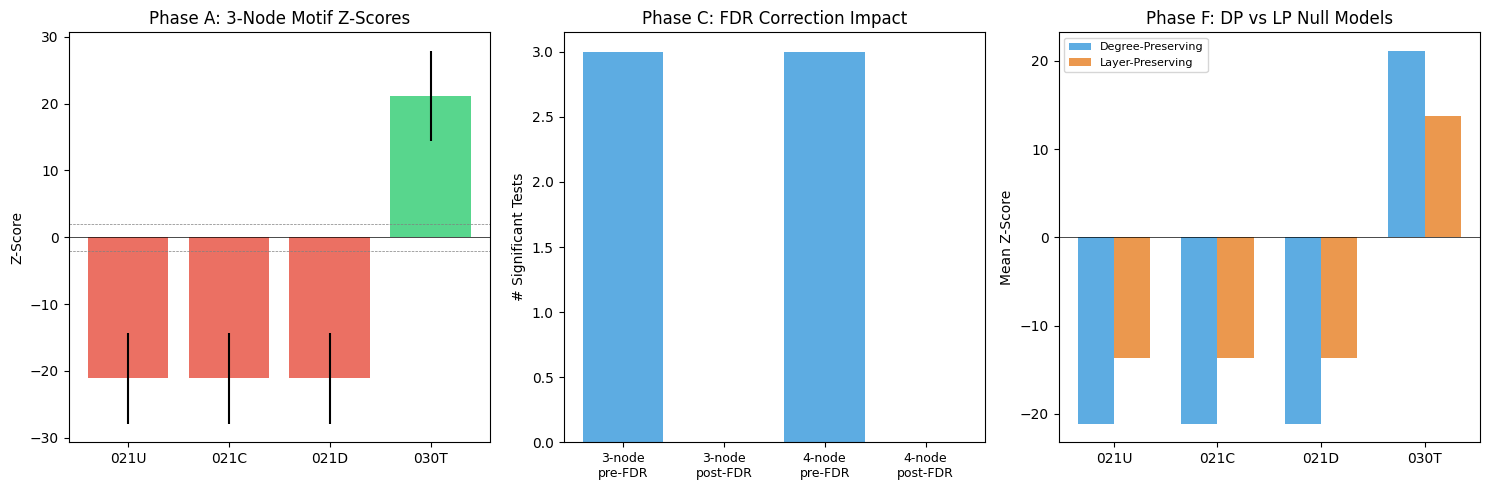


Figure saved to results_summary.png


In [14]:
# ── Results Table ──
print("=" * 70)
print("RESULTS SUMMARY")
print("=" * 70)

# Phase A summary
va = [r for r in res_a if not r.get("error")]
print(f"\n--- Phase A: 3-Node Motif Z-Scores ({len(va)} graphs, {N_NULLS_A} nulls each) ---")
print(f"{'Motif':<10} {'Label':<8} {'Median Z':>10} {'Mean Z':>10} {'Frac |Z|>2':>12}")
for mid in sorted(dag3.keys()):
    mk = str(mid)
    zs = [r["motif_results"][mk]["zscore"] for r in va if mk in r.get("motif_results", {})]
    if zs:
        zarr = np.array(zs)
        print(f"{mk:<10} {dag3[mid]['label']:<8} {float(np.median(zarr)):>10.2f} "
              f"{float(zarr.mean()):>10.2f} {float((np.abs(zarr) > 2).mean()):>12.3f}")

# Phase C summary
print(f"\n--- Phase C: FDR Correction ---")
if "3node" in res_c:
    c3 = res_c["3node"]
    print(f"  3-node: {c3['n_tests']} tests, {c3['n_rejected_pre_fdr']} sig pre-FDR -> {c3['n_rejected_post_fdr']} post-FDR")
if "4node" in res_c:
    c4 = res_c["4node"]
    print(f"  4-node: {c4['n_tests']} tests, {c4['n_rejected_pre_fdr']} sig pre-FDR -> {c4['n_rejected_post_fdr']} post-FDR")

# Phase F comparison
print(f"\n--- Phase F: Degree-Preserving vs Layer-Preserving ---")
if comp_f:
    print(f"{'Motif':<10} {'Label':<8} {'Mean Z(DP)':>12} {'Mean Z(LP)':>12} {'Diff':>8} {'Wilcoxon p':>12}")
    for mk in sorted(comp_f.keys()):
        c = comp_f[mk]
        wp = f"{c['wilcoxon_p']:.4f}" if c['wilcoxon_p'] is not None else "N/A"
        print(f"{mk:<10} {c['label']:<8} {c['mean_z_dp']:>12.2f} {c['mean_z_lp']:>12.2f} "
              f"{c['mean_diff']:>8.2f} {wp:>12}")

# ── Visualization ──
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Plot 1: 3-node Z-scores per motif
ax = axes[0]
motif_labels = []
motif_zscores = []
for mid in sorted(dag3.keys()):
    mk = str(mid)
    zs = [r["motif_results"][mk]["zscore"] for r in va if mk in r.get("motif_results", {})]
    if zs:
        motif_labels.append(dag3[mid]["label"])
        motif_zscores.append(zs)
if motif_zscores:
    positions = range(len(motif_labels))
    ax.bar(positions, [np.mean(z) for z in motif_zscores],
           yerr=[np.std(z) for z in motif_zscores] if len(motif_zscores[0]) > 1 else None,
           color=['#e74c3c' if np.mean(z) < 0 else '#2ecc71' for z in motif_zscores], alpha=0.8)
    ax.set_xticks(positions)
    ax.set_xticklabels(motif_labels)
    ax.set_ylabel("Z-Score")
    ax.set_title("Phase A: 3-Node Motif Z-Scores")
    ax.axhline(y=0, color='black', linewidth=0.5)
    ax.axhline(y=2, color='gray', linestyle='--', linewidth=0.5, label='|Z|=2')
    ax.axhline(y=-2, color='gray', linestyle='--', linewidth=0.5)

# Plot 2: FDR impact
ax = axes[1]
if "3node" in res_c and "4node" in res_c:
    categories = ['3-node\npre-FDR', '3-node\npost-FDR', '4-node\npre-FDR', '4-node\npost-FDR']
    values = [res_c["3node"]["n_rejected_pre_fdr"], res_c["3node"]["n_rejected_post_fdr"],
              res_c["4node"]["n_rejected_pre_fdr"], res_c["4node"]["n_rejected_post_fdr"]]
    colors = ['#3498db', '#2c3e50', '#3498db', '#2c3e50']
    ax.bar(range(len(categories)), values, color=colors, alpha=0.8)
    ax.set_xticks(range(len(categories)))
    ax.set_xticklabels(categories, fontsize=9)
    ax.set_ylabel("# Significant Tests")
    ax.set_title("Phase C: FDR Correction Impact")
elif "3node" in res_c:
    categories = ['Pre-FDR', 'Post-FDR']
    values = [res_c["3node"]["n_rejected_pre_fdr"], res_c["3node"]["n_rejected_post_fdr"]]
    ax.bar(range(len(categories)), values, color=['#3498db', '#2c3e50'], alpha=0.8)
    ax.set_xticks(range(len(categories)))
    ax.set_xticklabels(categories)
    ax.set_ylabel("# Significant Tests")
    ax.set_title("Phase C: FDR Correction Impact")

# Plot 3: DP vs LP Z-scores
ax = axes[2]
if comp_f:
    labels = [comp_f[mk]["label"] for mk in sorted(comp_f.keys())]
    dp_vals = [comp_f[mk]["mean_z_dp"] for mk in sorted(comp_f.keys())]
    lp_vals = [comp_f[mk]["mean_z_lp"] for mk in sorted(comp_f.keys())]
    x = np.arange(len(labels))
    w = 0.35
    ax.bar(x - w/2, dp_vals, w, label='Degree-Preserving', color='#3498db', alpha=0.8)
    ax.bar(x + w/2, lp_vals, w, label='Layer-Preserving', color='#e67e22', alpha=0.8)
    ax.set_xticks(x)
    ax.set_xticklabels(labels)
    ax.set_ylabel("Mean Z-Score")
    ax.set_title("Phase F: DP vs LP Null Models")
    ax.legend(fontsize=8)
    ax.axhline(y=0, color='black', linewidth=0.5)

plt.tight_layout()
plt.savefig("results_summary.png", dpi=100, bbox_inches="tight")
plt.show()
print("\nFigure saved to results_summary.png")